Building s simple chatbot using LSTM

First let's define the vocabulary

In [1]:
import json
import torch

with open("chatbot_dataset.json","r") as f:
  data=json.load(f)

PAD - pads short sequences to equal length in a batch

SOS - Start of Sequence

EOS - End Of Sequence

UNK - Unknown words not seen during training

In [3]:
PAD,SOS,EOS,UNK=0,1,2,3
special_tokens=["<PAD>","<SOS>","<EOS>","<UNK>"]

all_words = set()
for pair in data:
  for word in pair["input"].lower().split():
    all_words.add(word)
  for word in pair["response"].lower().split():
    all_words.add(word)
all_words

{'a',
 'about',
 'am',
 'are',
 'assistant',
 'bye',
 'can',
 'care',
 'chat',
 'chatbot',
 'course,',
 'day',
 'doing',
 'fine,',
 'good',
 'goodbye!',
 'great',
 'happy',
 'have',
 'hear',
 'hear!',
 'hello!',
 'help',
 'here',
 'hi',
 'how',
 'i',
 'is',
 'it?',
 'me',
 'morning',
 'morning!',
 'name',
 'need',
 'nice',
 'of',
 'sad',
 'sorry',
 'take',
 'talk',
 'tell',
 'thank',
 "that's",
 'that,',
 'to',
 'want',
 'welcome!',
 'what',
 'with',
 'you',
 "you're",
 'you?',
 'your'}

In [4]:
vocab=special_tokens+sorted(list(all_words))
word2idx={w:i for i,w in enumerate(vocab)}
idx2word={i:w for w,i in word2idx.items()}

In [6]:
vocab_size=len(vocab)
print(f"Vocabulary size : {vocab_size}")
print(f"word2idx sample : {dict(list(word2idx.items())[:8])}")

Vocabulary size : 57
word2idx sample : {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3, 'a': 4, 'about': 5, 'am': 6, 'are': 7}


In [7]:
def encode(sentence):
  return [word2idx.get(w,UNK) for w in sentence.lower().split()]+[EOS]
encode("how are you")

[29, 7, 53, 2]

Let's tokenize the dataset

In [8]:
import json
import numpy as np
with open("chatbot_dataset.json") as f:
  data=json.load(f)

In [9]:
inputs=[pair["input"] for pair in data]
responses=[pair["response"] for pair in data]
print(inputs)
print(responses)

['hi', 'how are you', 'what is your name', 'i am sad', 'i am happy', 'bye', 'what are you doing', 'can you help me', 'thank you', 'good morning']
['hello! how are you?', 'i am fine, how about you?', 'i am your chatbot assistant', 'i am sorry to hear that, want to talk about it?', "that's great to hear!", 'goodbye! take care', 'i am here to chat with you', 'of course, tell me what you need', "you're welcome!", 'good morning! have a nice day']


In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [12]:
tokenizer=Tokenizer(filters='',lower=True,oov_token="<OOV>")
tokenizer.fit_on_texts(inputs+responses)

In [13]:
vocab_size=len(tokenizer.word_index)+1
print(f"Vocabulary size : {vocab_size}")
print(f"Word index : {tokenizer.word_index}")

Vocabulary size : 55
Word index : {'<OOV>': 1, 'you': 2, 'i': 3, 'am': 4, 'to': 5, 'how': 6, 'are': 7, 'what': 8, 'your': 9, 'me': 10, 'good': 11, 'you?': 12, 'about': 13, 'hi': 14, 'is': 15, 'name': 16, 'sad': 17, 'happy': 18, 'bye': 19, 'doing': 20, 'can': 21, 'help': 22, 'thank': 23, 'morning': 24, 'hello!': 25, 'fine,': 26, 'chatbot': 27, 'assistant': 28, 'sorry': 29, 'hear': 30, 'that,': 31, 'want': 32, 'talk': 33, 'it?': 34, "that's": 35, 'great': 36, 'hear!': 37, 'goodbye!': 38, 'take': 39, 'care': 40, 'here': 41, 'chat': 42, 'with': 43, 'of': 44, 'course,': 45, 'tell': 46, 'need': 47, "you're": 48, 'welcome!': 49, 'morning!': 50, 'have': 51, 'a': 52, 'nice': 53, 'day': 54}


In [14]:
input_seqs=tokenizer.texts_to_sequences(inputs)
response_seqs=tokenizer.texts_to_sequences(responses)

In [15]:
max_len=max(
    max(len(s) for s in input_seqs),
    max(len(s) for s in response_seqs)
)

In [16]:
input_padded=pad_sequences(input_seqs,maxlen=max_len,padding="post")
response_padded = pad_sequences(response_seqs,maxlen=max_len,padding="post")

In [18]:
print(f"\nMax sequence length: {max_len}")
print(f"Input shape:    {input_padded.shape}")
print(f"Response shape: {response_padded.shape}")
print(f"\nSample — 'hi' encodes to: {input_padded[0]}")


Max sequence length: 11
Input shape:    (10, 11)
Response shape: (10, 11)

Sample — 'hi' encodes to: [14  0  0  0  0  0  0  0  0  0  0]


Building the lstm model

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense
import numpy as np

In [21]:
X=input_padded
y=response_padded

In [23]:
from tensorflow.keras.utils import to_categorical
y_onehot=to_categorical(y,num_classes=vocab_size)

In [25]:
model=Sequential([
    Embedding(input_dim=vocab_size,output_dim=32,input_length=max_len),
    LSTM(64,return_sequences=True),
    Dense(vocab_size,activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [27]:
model.build(input_shape=(None,max_len))
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 11, 32)         │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 11, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 11, 55)         │         3,575 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,167 (117.84 KB)

 Trainable params: 30,167 (117.84 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
history=model.fit(
    X,
    y_onehot,
    epochs=100,
    batch_size=2,
    verbose=1
)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6636 - loss: 1.1979
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7000 - loss: 1.1761
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6636 - loss: 1.1688
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6455 - loss: 1.1678
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6727 - loss: 1.1993
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6636 - loss: 1.1733
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6818 - loss: 1.1045
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7000 - loss: 1.1127
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6909 - loss: 1.0766
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6818 - loss: 1.0600
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7182 - loss: 1.0384
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7364 - lo

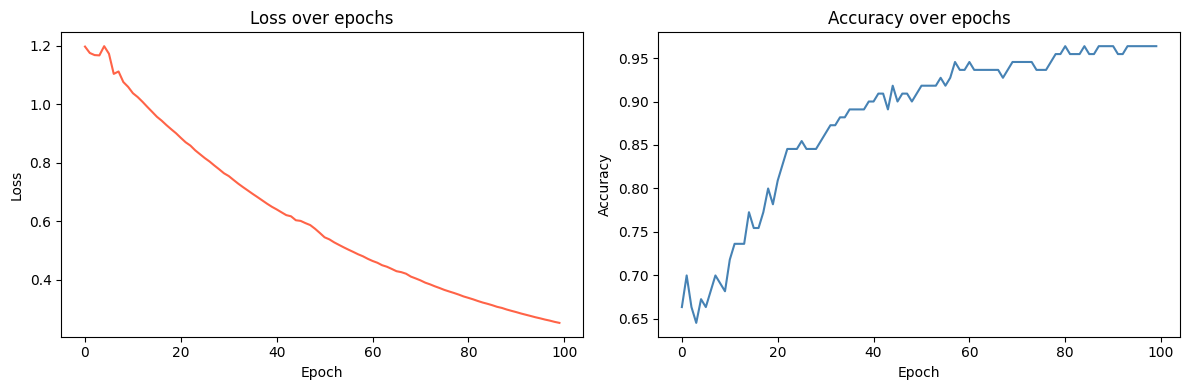

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], color='tomato')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], color='steelblue')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()

In [34]:
def generate_response(input_text):
    seq = tokenizer.texts_to_sequences([input_text])
    padded = pad_sequences(seq, maxlen=max_len, padding='post')

    prediction = model.predict(padded, verbose=0)

    predicted_indices = np.argmax(prediction[0], axis=-1)
    response_words = []
    for idx in predicted_indices:
        if idx == 0:
            continue
        word = tokenizer.index_word.get(idx, "")
        if word:
            response_words.append(word)

    return " ".join(response_words)

test_inputs = [
    "hi",
    "how are you",
    "what is your name",
    "thank you",
    "bye"
]

print("=" * 40)
print("        CHATBOT RESPONSES")
print("=" * 40)
for text in test_inputs:
    response = generate_response(text)
    print(f"You : {text}")
    print(f"Bot : {response}")
    print("-" * 40)


        CHATBOT RESPONSES
You : hi
Bot : hello! how are you?
----------------------------------------
You : how are you
Bot : i am fine, how about you?
----------------------------------------
You : what is your name
Bot : i am your chatbot assistant
----------------------------------------
You : thank you
Bot : you're
----------------------------------------
You : bye
Bot : goodbye! take care
----------------------------------------
